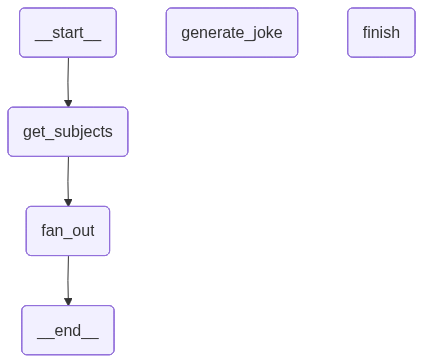

In [3]:
from typing import List, Annotated
import operator

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from pydantic import BaseModel
from IPython.display import display, Image

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


class JokeState(BaseModel):
    topic: str
    subjects: List[str] = []
    jokes: Annotated[List[str], operator.add] = []


def get_subjects(state: JokeState):
    subjects = [f"{state.topic} - subject {i}" for i in range(1, 4)]
    return {"subjects": subjects}


def fan_out(state: JokeState):
    return [
        Send("generate_joke", {"subject": s, "topic": state.topic})
        for s in state.subjects
    ]


def generate_joke(state: dict):
    text = f"Tell me a short joke about {state['subject']}."
    resp = llm.invoke([HumanMessage(content=text)])
    return {"jokes": [resp.content.strip()]}


def finish(state: JokeState):
    return state


builder = StateGraph(JokeState)

builder.add_node("get_subjects", get_subjects)
builder.add_node("fan_out", fan_out)
builder.add_node("generate_joke", generate_joke)
builder.add_node("finish", finish)

builder.add_edge(START, "get_subjects")
builder.add_edge("get_subjects", "fan_out")

builder.add_conditional_edges("fan_out", fan_out)

builder.add_edge("generate_joke", "finish")
builder.add_edge("finish", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))